# Génération d'un tableau de représentation


Pour une liste d'activations `models_idx_act = [(model_name_1, timestamp_1, [idx_act])]` dont les déconvolutions ont été calculées durant la session `id_session` avec un réseau `model_name` et sauvées dans des fichiers `.pt` au sein du répertoire `save_session_dir`, regénération des images et création d'un tableau HTML à insérer dans le rapport sous Obsidian.

Pour deux réseaux, on donne `models_idx_act = [(model_name_1, timestamp_1, [idx_act]), (model_name_2, timestamp_2, [idx_act])]`.

1. Lire le fichier .csv contenant l'ensemble des informations.
2. Regrouper les activations par neurone.
3. Pour chaque neurone, charger le fichier .pt correspondant.
4. Récupérer les tenseurs de déconvolution.
5. Recréer la combinaison d'images
6. Sauver la combinaison dans le fichier `{model_name}-L{idx_layer}-n{channel}_{row}_{col}-k{topk}.png`

## Modules

In [59]:
import os
from typing import Tuple
import torch
from torchvision import transforms as T
from torchvision.io import decode_image
import pandas as pd
from PIL import ImageDraw, Image, ImageFont
import matplotlib.pyplot as plt

from datasets import DATASET_3, imagenet_mean, imagenet_std
from utils.utils_images import display_images_list_grid, to_0_1
from imagenet_labels import imagenet1K_labels_to_names

## Constantes

In [171]:
dataset_dir = DATASET_3["path"]
#patchwork_dir = "/Users/me/Temp/CNAM"
patchwork_dir = "/Users/me/Dropbox (Compte personnel)/Perso NG/Cours et Mooc/CNAM/RCP209 - Apprentissage statistique - modélisation décisionnelle et apprentissage profond/Project CNAM RCP209/rebuilt_images"
receptive_field_color = "red"
receptive_field_width = 3

## Définitions

In [3]:
def merge_input_and_deconv(background_image: torch.Tensor, output_deconv: torch.Tensor, receptive_field: Tuple[int, ...], alpha: float=0.75) -> Image.Image:
    assert alpha >= 0 and alpha <= 1, "Alpha must be between 0 and 1"

    ((top, left), (bottom, right)) = receptive_field
    background_image = T.functional.to_pil_image(background_image)
    output_deconv = T.functional.to_pil_image(output_deconv).crop((left, top, right, bottom))

    # Ajouter couche alpha pour superposer l'image de sortie sur l'image de fond
    background_image = background_image.convert("RGBA")
    output_resized = output_deconv.convert("RGBA")
    
    # Créer un masque pour la transparence (optionnel)
    mask = Image.new("L", output_resized.size, int(255 * alpha))

    # Coller l'image de sortie sur l'image de fond
    background_image.paste(output_resized, (left, top), mask)

    return background_image.convert("RGB")

In [4]:
# Conversion en tuple d'entiers
convert_tuple = lambda string_tuple: tuple(map(int, string_tuple.strip("()").split(",")))

# Conversion en tuple de tuples d'entiers
convert_tuple_of_tuples = lambda string_tuple_of_tuples: tuple(tuple(map(int, inner.strip("()").split(","))) for inner in string_tuple_of_tuples.strip("()").split("), ("))

In [155]:
def create_image_grid(
        images,
        rows=1,
        cell_size=(224, 224),
        padding=0, # (top/left, interX/interY, bottom/right)
        background_color=(255, 255, 255),
        title=None,
        font_size=0,
        resize=1
        ):
    """
    Crée une grille d'images.

    :param images: Liste des chemins des images ou objets PIL.Image.
    :param rows: Nombre de lignes dans la grille.
    :param cell_size: Taille de chaque cellule (largeur, hauteur).
    :param padding: Espacement entre les cellules.
    :param background_color: Couleur de fond de la grille.
    :return: Image PIL représentant la grille.
    """
    if type(padding) == int:
        padding = ((padding, padding, padding), (padding, padding, padding))
    padding = (
        padding[0],
        (max(font_size, padding[1][0], padding[1][2]), padding[1][1], padding[1][2])
        )

    cols = (len(images) + rows - 1) // rows  # Calcul du nombre de colonnes
    grid_width = cols * cell_size[0] + (cols - 1) * padding[0][1] + padding[0][0] + padding[0][2]
    grid_height = rows * cell_size[1] + (rows - 1) * padding[1][1] + padding[1][0] + padding[1][2]

    grid_image = Image.new("RGB", (grid_width, grid_height), background_color)
    #print(f"Grid size: {grid_width}x{grid_height}")
    for idx, img in enumerate(images):
        img = img.resize(cell_size, Image.Resampling.NEAREST)

        row, col = divmod(idx, cols)
        x = padding[0][0] + col * (cell_size[0] + padding[0][1])
        y = padding[1][0] + row * (cell_size[1] + padding[1][1])

        grid_image.paste(img, (x, y));
    
    if resize > 1:
        grid_image = grid_image.resize((grid_image.width//resize, grid_image.height//resize), Image.Resampling.NEAREST)

    if title:
        draw = ImageDraw.Draw(grid_image);
        font_path = "/System/Library/Fonts/Supplemental/Arial Bold.ttf"
        font = ImageFont.truetype(font_path, font_size)
        box = font.getbbox(title)
        text_width = font.getlength(title)
        text_x = (grid_width//resize - text_width) // 2
        text_y = min(1, padding[1][0] - font_size)
        draw.text((text_x, text_y), title, fill=(0, 0, 0), font=font);
    
    return grid_image

In [175]:
pil_to_tensor = T.PILToTensor()

geo_transforms = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
])

inv_mean = [-m/s for m, s in zip(imagenet_mean, imagenet_std)]
inv_std = [1/s for s in imagenet_std]
inv_normalize = T.Normalize(inv_mean, inv_std)

def get_image_patchwork(image, output_deconv, receptive_field, title=""):
    ((top, left), (bottom, right)) = receptive_field
    image_resized = geo_transforms(image)

    image_resized_receptive_field = T.functional.to_pil_image(image_resized)
    img_draw = ImageDraw.Draw(image_resized_receptive_field)
    img_draw.rectangle(
        [(left, top), (right, bottom)],
        width=receptive_field_width,
        outline=receptive_field_color
        )

    output_deconv_in_pixel_space = to_0_1(inv_normalize(output_deconv))

    output_deconv_receptive_field = T.functional.to_pil_image(output_deconv_in_pixel_space)
    img_draw = ImageDraw.Draw(output_deconv_receptive_field)
    img_draw.rectangle(
        [(left, top), (right, bottom)],
        width=receptive_field_width,
        outline=receptive_field_color
        )
    
    input_and_deconv = merge_input_and_deconv(
        image_resized, output_deconv_in_pixel_space,
        receptive_field, alpha=0.95
    )
    
    images = [
        image_resized,
        pil_to_tensor(image_resized_receptive_field),
        pil_to_tensor(output_deconv_receptive_field),
        image_resized[:, top:bottom+1, left:right+1],
        output_deconv_in_pixel_space[:, top:bottom+1, left:right+1],
        pil_to_tensor(input_and_deconv),
        ]
    
    patchwork = create_image_grid(
        [T.functional.to_pil_image(images) for images in images],
        title=title,
        font_size = 20,
        resize = 1,
        padding=((10, 5, 10), (32, 0, 2)),
        );
    #display(patchwork)
    return patchwork
    #return display_images_list_grid(images, per_rows=6, figsize=(8, 2), title=title, no_plt_show=True);

### HTML

In [35]:
def get_html_table_1_cnn(title_table: str, filenames, width=350) -> str:
    table_rows_html = "\n".join([f'<img src="{name}" width="{width}"><br>' for name in filenames])
    rowspan = len(filenames)
    html = f"""<table>
    <tr><th colspan="2">{title_table}</th></tr>
    <tr>
    <td rowspan="{rowspan}" style="text-align: justify; vertical-align: middle">TEXT</td>
    <td style="text-align: center; vertical-align: middle">{table_rows_html}</td>
    </tr>
    </table>"""

    print(html)


def get_html_table_1_cnn_B(title_table: str, filenames, width=350) -> str:
    table_rows_html = "\n".join([f'<tr><td style="text-align: center; vertical-align: middle"><img src="{name}" width="{width}"></td></tr>' for name in filenames[1:]])

    rowspan = len(filenames)

    html = f"""<table>
    <tr><th colspan="2">{title_table}</th></tr>
    <tr>
    <td rowspan="{rowspan}" style="text-align: justify; vertical-align: middle">TEXT</td>
    <td style="text-align: center; vertical-align: middle"><img src="{filenames[0]}" width="350"></td>
    </tr>
    {table_rows_html}
    </table>"""

    print(html)

In [36]:
def get_html_table_2_cnn(
        title_table: str, filenames1, filenames2, 
        model_1 = "AlexNet", model_2 = "VGG16", width=350) -> str:
    assert len(filenames1) == len(filenames2), "Les deux listes de noms de fichiers doivent avoir la même longueur"

    table_rows_html_l= "\n".join([f'<img src="{name}" width="{width}"><br>' for name in filenames1])
    table_rows_html_r = "\n".join([f'<img src="{name}" width="{width}"><br>' for name in filenames2])
    
    rowspan = len(filenames1) + 1
    html = f"""<table>
    <tr><th colspan="3">{title_table}</th></tr>
    <tr>
    <td rowspan="{rowspan}" style="text-align: justify; vertical-align: middle">TEXT</td>
    <td style="text-align: center; vertical-align: middle">{model_1}</td>
    <td style="text-align: center; vertical-align: middle">{model_2}</td>
    </tr>
    <tr>
    <td style="text-align: center; vertical-align: middle">{table_rows_html_l}</td>
    <td style="text-align: center; vertical-align: middle">{table_rows_html_r}</td>
    </tr>
    </table>"""

    print(html)


def get_html_table_2_cnn_B(
        title_table: str, filenames1, filenames2,
        model_1 = "AlexNet", model_2 = "VGG16", width=350) -> str:
    assert len(filenames1) == len(filenames2), "Les deux listes de noms de fichiers doivent avoir la même longueur"

    table_rows_html = "\n".join([f'<tr><td style="text-align: center; vertical-align: middle"><img src="{name1}" width="{width}"></td><td style="text-align: center; vertical-align: middle"><img src="{name2}" width="{width}"></td></tr>' for name1, name2 in zip(filenames1, filenames2)])
    
    rowspan = len(filenames1) + 1
    html = f"""<table>
    <tr><th colspan="3">{title_table}</th></tr>
    <tr>
    <td rowspan="{rowspan}" style="text-align: justify; vertical-align: middle">TEXT</td>
    <td style="text-align: center; vertical-align: middle">{model_1}</td>
    <td style="text-align: center; vertical-align: middle">{model_2}</td>
    </tr>
    {table_rows_html}
    </table>"""

    print(html)

## Process

In [191]:
#idx_act_max_activations = {("alexnet", "20250428_185304"): [37, 136, 226, 406, 469]} # Attention, base 1

idx_act_max_activations = [
    ("alexnet", "20250429_182543", [37, 136, 226, 406, 469]), # Attention, base 1
    ("vgg16", "20250429_193742", [73, 100, 145, 208, 253]), # Attention, base 1
]

idx_act_first_conv_blocks = [
    ("alexnet", "20250429_182543", list(range(1, 9*9+1, 9))), # Attention, base 1
    ("vgg16", "20250429_193742", list(range(1, 9*9, 9))), # Attention, base 1
]

idx_act_gabor = [
    ("alexnet", "20250429_182543", list(range(1, 9*9+1, 9))), # Attention, base 1
    ("vgg16", "20250429_193742", list(range(82, 82 + 9*9, 9))), # Attention, base 1
]

idx_act_rep_for_class = [
    ("vgg16", "20250429_193742", list(range(271, 275+1))), # Attention, base 1
    ("vgg16", "20250429_193742", list(range(276, 279+1))), # Attention, base 1
]


idx_interp_or_not = [
    ("alexnet", "20250429_182543", list(range(226, 234+1))), # Attention, base 1
    ("alexnet", "20250429_182543", list(range(298, 306+1))), # Attention, base 1
]


idx_last_blocs = [
    ("alexnet", "20250429_182543", [424, 433, 442, 451, 460]), # Attention, base 1
    ("vgg16", "20250429_193742", [235, 244, 253, 262, 271]), # Attention, base 1
]

idx_act_invariance_rep_variance_contexte = [
    ("alexnet", "20250429_182543", list(range(136, 144+1))), # Attention, base 1
    ("vgg16", "20250429_193742", list(range(208, 216+1))), # Attention, base 1
]


idx_act_rep_kind_of = [
    # color, shape, texture, frequency
    ("alexnet", "20250429_182543", [73, 145, 307, 47]), # Attention, base 1
    #("vgg16", "20250429_193742", [100, 208, ]), # Attention, base 1
]




In [196]:
################################################################################
save_session_dir = "/Users/me/Temp/CNAM/deconv_sessions" # Répertoire de sauvegarde
models_idx_act = idx_act_invariance_rep_variance_contexte
group_name = "group_invariance_rep_variance_contexte"
################################################################################

0


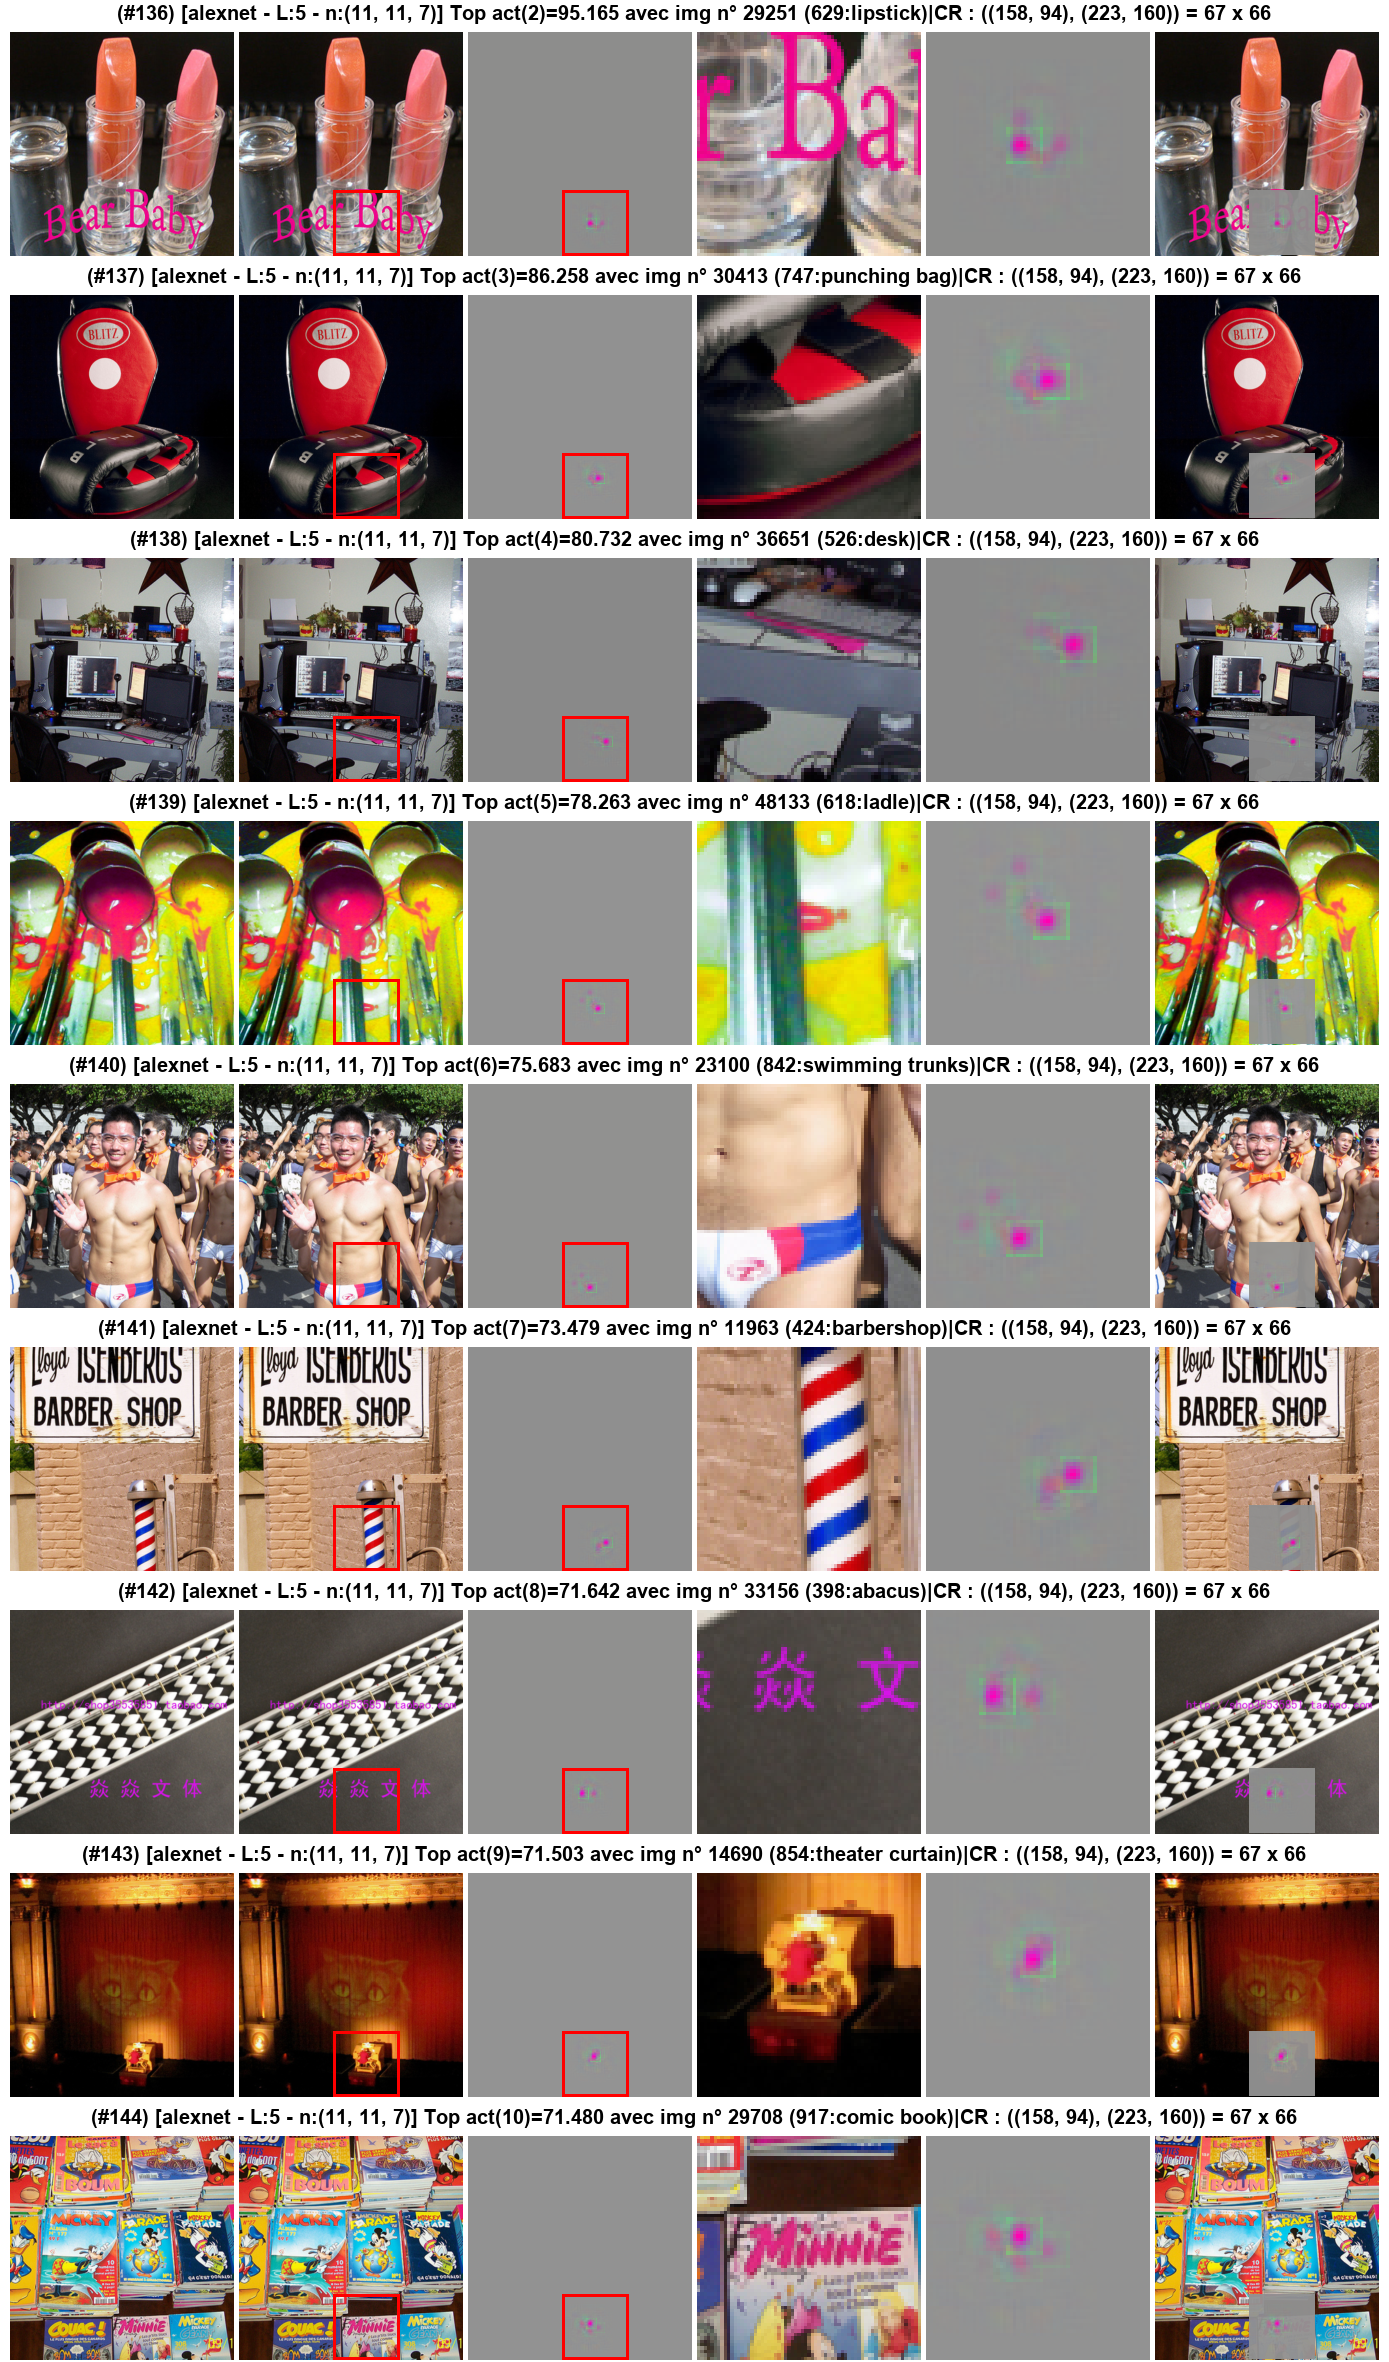

1


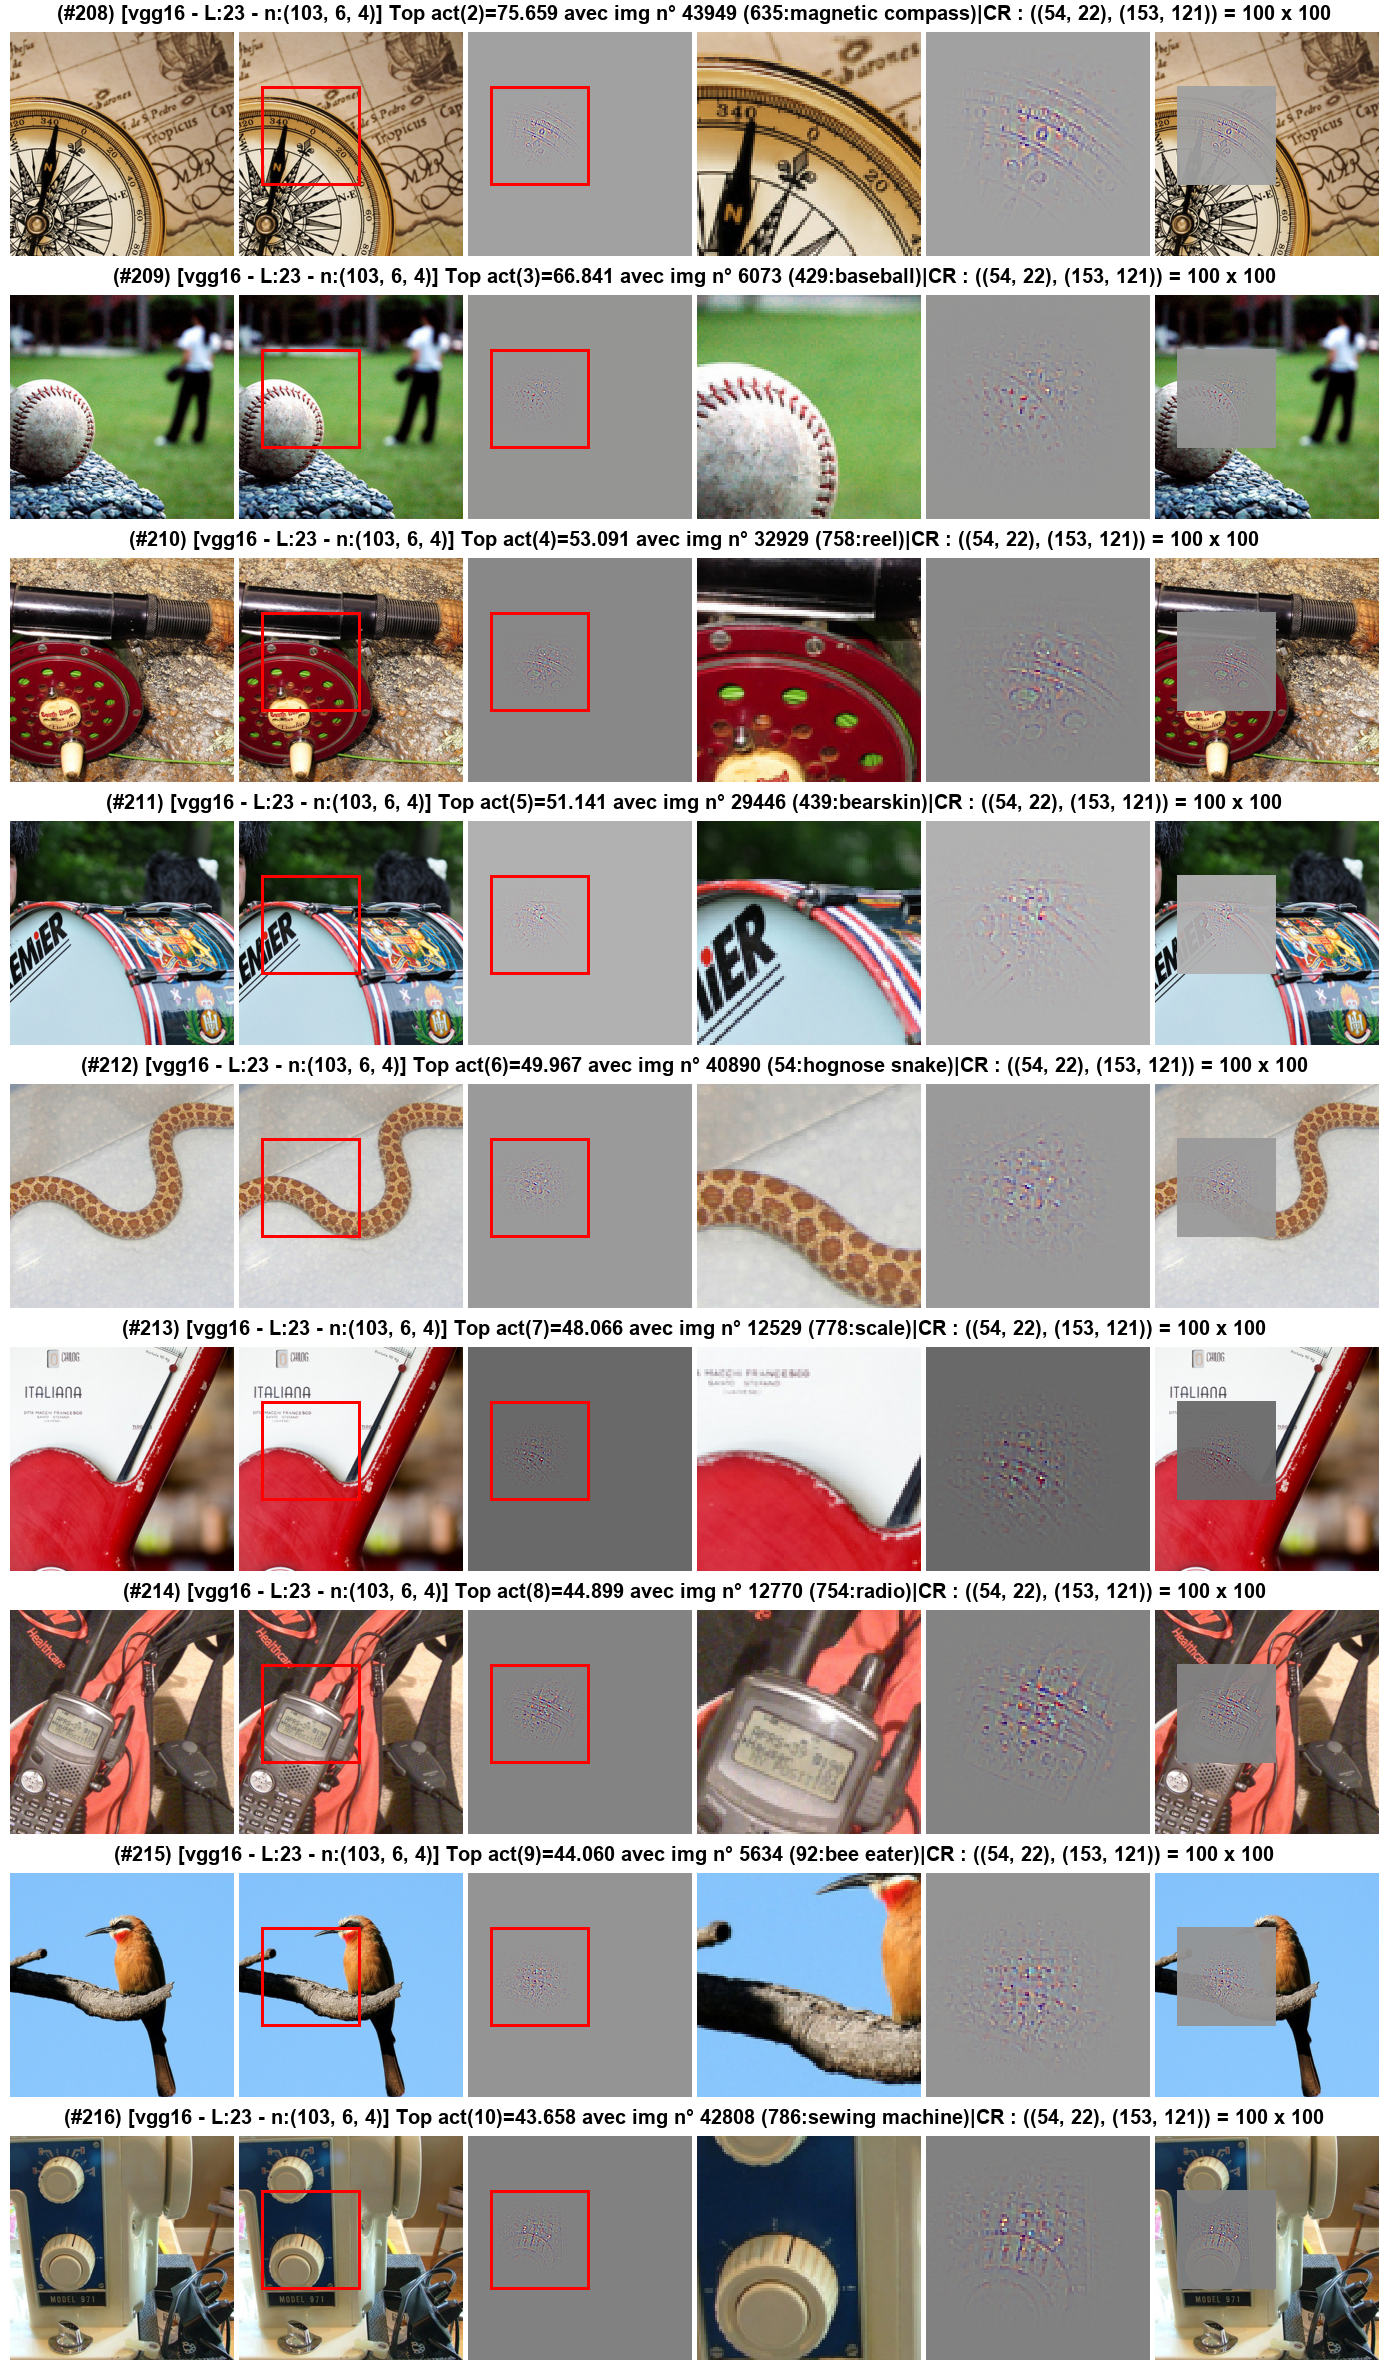

In [197]:
all_filenames = []

for i, (model_name, timestamp_session, idx_act) in enumerate(models_idx_act):
    id_session = f"{model_name}_{timestamp_session}"
    session_dir = os.path.join(save_session_dir, id_session)
    session_csv = os.path.join(session_dir, f"{id_session}_.csv")

    # Lecture du fichier .csv
    df = pd.read_csv(session_csv)

    # Filtrer les lignes du dataframe où la colonne "ID Act" contient les valeurs de la liste l
    filtered_df = df[df["ID Act"].isin(idx_act)]
    #print(filtered_df)

    fix = 1 if timestamp_session in ["20250428_185304", "20250428_221211"] else 0
    filenames = []
    patchworks = []
    for _, row_act in filtered_df.iterrows():
        i_result = row_act["ID Act"]
        idx_layer = row_act["ID couche"]
        idx_neuron = row_act["ID neurone"]
        coord = convert_tuple(row_act["Coord neurone"])
        topk = row_act["ID TopK"]
        activation = row_act["Activation"]
        receptive_field = convert_tuple_of_tuples(row_act["Champ réceptif"])
        idx_file = row_act["ID Fichier"] + fix # Sauver dans le fichier CSV en base 0 lié au Dataset
        idx_label = row_act["Classe"]

        class_name = imagenet1K_labels_to_names[idx_label].lower()

        filename = f"ILSVRC2012_val_{idx_file:08d}.JPEG"
        image = decode_image(os.path.join(dataset_dir, filename), mode="RGB")

        filename = f"deconvs_neuron_L{idx_layer:02d}_n{idx_neuron:03d}.pt"
        deconvolutions_tensor = torch.load(os.path.join(session_dir, filename))
        
        output_deconv = deconvolutions_tensor[topk-1]

        ((top, left), (bottom, right)) = receptive_field
        info1 = f"(#{i_result:3d}) [{model_name} - L:{idx_layer} - n:{coord}] Top act({topk+1})={activation:.3f} avec img n° {idx_file} ({idx_label}:{class_name})"
        info2 = f"CR : {receptive_field} = {right-left+1} x {bottom-top+1}"
        title = info1 + "|" + info2

        patchworks.append(
            get_image_patchwork(image, output_deconv, receptive_field, title)
        )
        #fig, axs = get_image_patchworh(image, output_deconv, receptive_field, title)
        #figs.append(fig)

        #channel, row, col = coord
        #filename = f"{model_name}-L{idx_layer}-n{channel}_{row}_{col}-k{topk}.png"
        #filenames.append(filename)
        #fig.savefig(os.path.join(patchwork_dir, filename), format="png", dpi=300, transparent=False)
    print(i)
    cell_size = patchworks[0].size
    image_patchwork = create_image_grid(
        patchworks, 
        rows=len(patchworks),
        cell_size=cell_size,
        padding=((0, 0, 0), (0, 5, 0)),
        )
    display(image_patchwork)
    image_patchwork.save(
        #os.path.join(patchwork_dir, f"{model_name}_{group_name}.png"),
        os.path.join(patchwork_dir, f"{model_name}_{group_name}_{i}.png"),
        format="png", dpi=(300,300)
        )
    

    #aggregate_figures(figs, len(figs), 1, figsize=(8, 2))
    #print(filenames)
    #all_filenames.append(filenames)


In [22]:
get_html_table_1_cnn(
    title_table="TITRE",
    filenames=all_filenames[0]
)

<table>
    <tr><th colspan="2">TITRE</th></tr>
    <tr>
    <td rowspan="4" style="text-align: justify; vertical-align: middle">TEXT</td>
    <td style="text-align: center; vertical-align: middle"><img src="alexnet-L2-n27_7_16-k2.png" width="350"><br>
<img src="alexnet-L2-n35_25_0-k1.png" width="350"><br>
<img src="alexnet-L5-n137_1_6-k1.png" width="350"><br>
<img src="alexnet-L7-n28_3_0-k1.png" width="350"><br></td>
    </tr>
    </table>


In [23]:
get_html_table_1_cnn_B(
    title_table="TITRE",
    filenames=all_filenames[0]
)

<table>
    <tr><th colspan="2">TITRE</th></tr>
    <tr>
    <td rowspan="4" style="text-align: justify; vertical-align: middle">TEXT</td>
    <td style="text-align: center; vertical-align: middle"><img src="alexnet-L2-n27_7_16-k2.png" width="350"></td>
    </tr>
    <tr><td style="text-align: center; vertical-align: middle"><img src="alexnet-L2-n35_25_0-k1.png" width="350"></td></tr>
<tr><td style="text-align: center; vertical-align: middle"><img src="alexnet-L5-n137_1_6-k1.png" width="350"></td></tr>
<tr><td style="text-align: center; vertical-align: middle"><img src="alexnet-L7-n28_3_0-k1.png" width="350"></td></tr>
    </table>


In [24]:
get_html_table_2_cnn(
    title_table="TITRE",
    filenames1=all_filenames[0],
    filenames2=all_filenames[1]
)

IndexError: list index out of range

In [ ]:
get_html_table_2_cnn_B(
    title_table="TITRE",
    filenames1=all_filenames[0],
    filenames2=all_filenames[1],
    model_1="AlexNet",
    model_2="VGG16"
)

<table>
    <tr><th colspan="3">TITRE</th></tr>
    <tr>
    <td rowspan="10" style="text-align: justify; vertical-align: middle">TEXT</td>
    <td style="text-align: center; vertical-align: middle">AlexNet</td>
    <td style="text-align: center; vertical-align: middle">VGG16</td>
    </tr>
    <tr><td style="text-align: center; vertical-align: middle"><img src="alexnet-L5-n11_11_7-k1.png" width="350"></td><td style="text-align: center; vertical-align: middle"><img src="vgg16-L23-n103_6_4-k1.png" width="350"></td></tr>
<tr><td style="text-align: center; vertical-align: middle"><img src="alexnet-L5-n11_11_7-k2.png" width="350"></td><td style="text-align: center; vertical-align: middle"><img src="vgg16-L23-n103_6_4-k2.png" width="350"></td></tr>
<tr><td style="text-align: center; vertical-align: middle"><img src="alexnet-L5-n11_11_7-k3.png" width="350"></td><td style="text-align: center; vertical-align: middle"><img src="vgg16-L23-n103_6_4-k3.png" width="350"></td></tr>
<tr><td style="te